# Download Dataset

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jrlFErc5KNJtiRgTqF72")
project = rf.workspace("techmanthanobjectdetection").project("techmanthan_object_detection")
version = project.version(1)
dataset = version.download("yolov8")


In [ ]:
!pip install ultralytics

# Train Model

In [ ]:
from ultralytics import YOLO
import os

# Load model (YOLOv8n)
model = YOLO("yolov8n.pt")

# Train the model
model.train(
    data='TechManthan_Object_Detection-1/data.yaml',
    epochs=50,
    imgsz=640,
    patience = 20, # for early stopping
    val = True, # do validation during training
    project="runs/train",
    name="yolov8n_custom",
    exist_ok=True,
    verbose=True
)

# Validate the model
metrics = model.val()
print("Validation Results:", metrics)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 124MB/s]


Ultralytics 8.3.152 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=TechManthan_Object_Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, po

100%|██████████| 755k/755k [00:00<00:00, 25.0MB/s]

Overriding model.yaml nc=80 with nc=9

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...


50 epochs completed in 0.012 hours.
Optimizer stripped from runs/train/yolov8n_custom/weights/last.pt, 6.3MB
Optimizer stripped from runs/train/yolov8n_custom/weights/best.pt, 6.3MB

Validating runs/train/yolov8n_custom/weights/best.pt...
Ultralytics 8.3.152 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 10.42it/s]


                   all          7         40      0.753      0.822      0.885      0.619
                 chair          3          3      0.426          1      0.995      0.513
                   cup          7          9          1      0.733       0.88      0.571
              keyboard          4          4          1          0      0.995      0.738
                laptop          4          4      0.686          1      0.845       0.59
               monitor          6          6      0.796          1      0.995      0.803
                 mouse          5          5      0.899          1      0.995      0.754
              notebook          3          3      0.505          1      0.597      0.352
                 plant          3          3      0.695      0.667      0.666        0.5
          water_bottle          3          3      0.766          1      0.995      0.752
Speed: 0.2ms preprocess, 4.0ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to runs/train/

val: Scanning /content/TechManthan_Object_Detection-1/valid/labels.cache... 7 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7/7 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  6.96it/s]


                   all          7         40      0.753      0.822      0.885      0.619
                 chair          3          3      0.426          1      0.995      0.513
                   cup          7          9          1      0.735       0.88      0.565
              keyboard          4          4          1          0      0.995      0.742
                laptop          4          4      0.686          1      0.845       0.59
               monitor          6          6      0.796          1      0.995      0.803
                 mouse          5          5      0.899          1      0.995      0.754
              notebook          3          3      0.505          1      0.597      0.352
                 plant          3          3      0.695      0.667      0.666        0.5
          water_bottle          3          3      0.766          1      0.995      0.752
Speed: 1.1ms preprocess, 8.6ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/train/

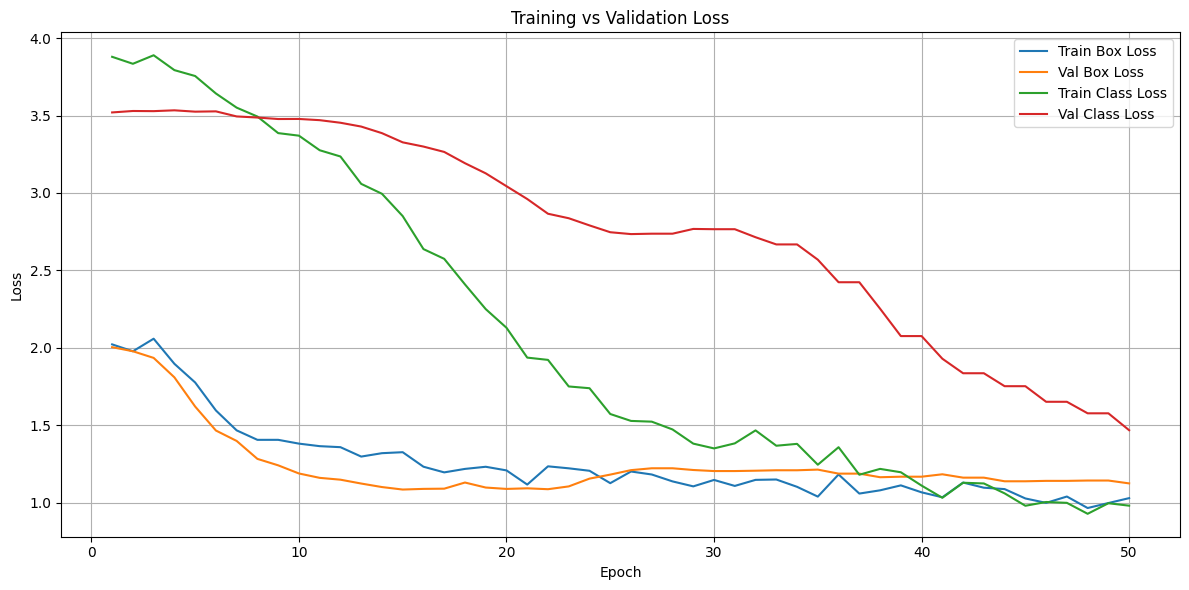

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/content/runs/train/yolov8n_custom/results.csv')

plt.figure(figsize=(12, 6))
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
plt.plot(df['epoch'], df['train/cls_loss'], label = 'Train Class Loss')
plt.plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.tight_layout()


image 1/1 /content/TechManthan_Object_Detection-1/valid/images/VID_20250610_145930_mp4-0001_jpg.rf.d58ef97e604cf1e88c0b631db87655b0.jpg: 640x640 1 chair, 1 laptop, 17.5ms
Speed: 6.4ms preprocess, 17.5ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'chair', 1: 'cup', 2: 'keyboard', 3: 'laptop', 4: 'monitor', 5: 'mouse', 6: 'notebook', 7: 'plant', 8: 'water_bottle'}
obb: None
orig_img: array([[[104, 101, 210],
        [104, 101, 210],
        [104, 101, 210],
        ...,
        [140, 129, 231],
        [140, 129, 231],
        [140, 129, 231]],

       [[104, 101, 210],
        [104, 101, 210],
        [104, 101, 210],
        ...,
        [141, 130, 232],
        [141, 130, 232],
        [141, 130, 232]],

       [[104, 101, 210],
        [104, 101, 210],
        [104, 101, 210],
        ...,
        [142, 131, 233],
  

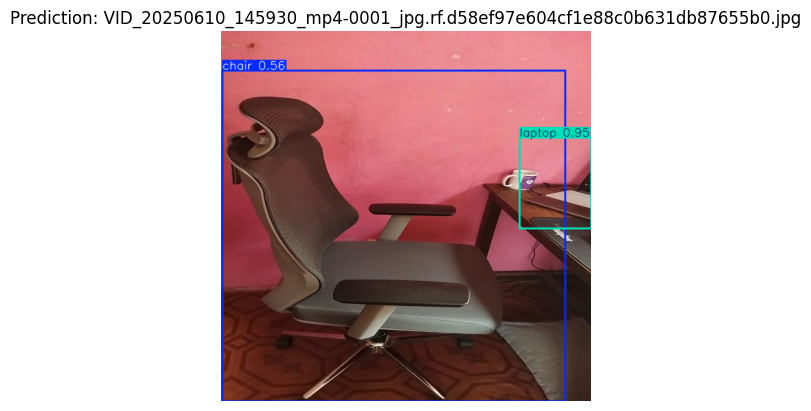


image 1/1 /content/TechManthan_Object_Detection-1/valid/images/VID_20250610_145930_mp4-0008_jpg.rf.c06fe7719b62b53baef439098177876d.jpg: 640x640 1 chair, 1 laptop, 1 monitor, 9.3ms
Speed: 2.8ms preprocess, 9.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'chair', 1: 'cup', 2: 'keyboard', 3: 'laptop', 4: 'monitor', 5: 'mouse', 6: 'notebook', 7: 'plant', 8: 'water_bottle'}
obb: None
orig_img: array([[[106, 102, 207],
        [106, 102, 207],
        [106, 102, 207],
        ...,
        [ 80,  73, 188],
        [ 80,  73, 188],
        [ 80,  73, 188]],

       [[106, 102, 207],
        [106, 102, 207],
        [106, 102, 207],
        ...,
        [ 80,  73, 188],
        [ 80,  73, 188],
        [ 80,  73, 188]],

       [[106, 102, 207],
        [106, 102, 207],
        [106, 102, 207],
        ...,
        [ 80,  73,

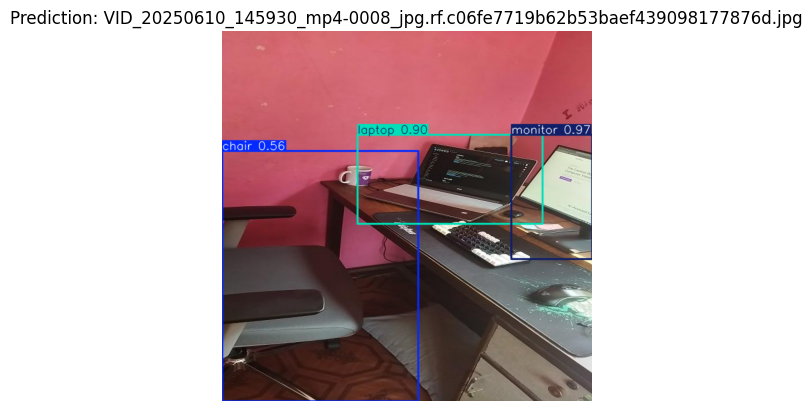


image 1/1 /content/TechManthan_Object_Detection-1/valid/images/VID_20250610_145930_mp4-0011_jpg.rf.e8de6926867c27c59a87cab41fbbcfc4.jpg: 640x640 1 chair, 1 laptop, 1 monitor, 1 notebook, 9.3ms
Speed: 3.2ms preprocess, 9.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'chair', 1: 'cup', 2: 'keyboard', 3: 'laptop', 4: 'monitor', 5: 'mouse', 6: 'notebook', 7: 'plant', 8: 'water_bottle'}
obb: None
orig_img: array([[[102,  97, 206],
        [102,  97, 206],
        [102,  97, 206],
        ...,
        [ 91,  85, 194],
        [ 91,  85, 194],
        [ 91,  85, 194]],

       [[102,  97, 206],
        [102,  97, 206],
        [102,  97, 206],
        ...,
        [ 91,  85, 194],
        [ 91,  85, 194],
        [ 91,  85, 194]],

       [[102,  97, 206],
        [102,  97, 206],
        [102,  97, 206],
        ...,
      

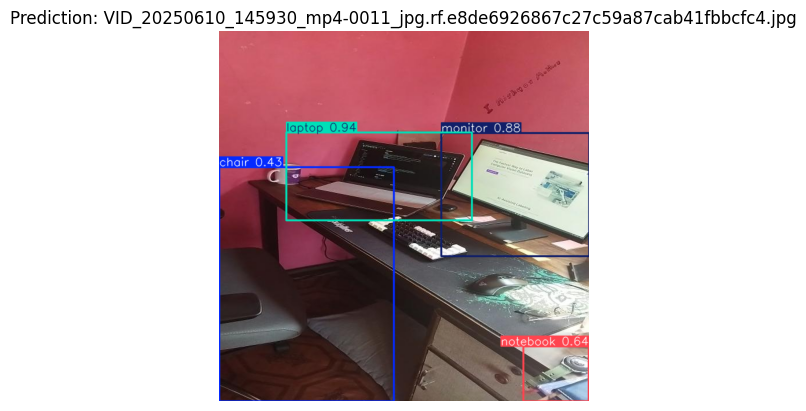


image 1/1 /content/TechManthan_Object_Detection-1/valid/images/VID_20250610_145930_mp4-0012_jpg.rf.fa26f9020bd32a6d057ecbcdf319ece1.jpg: 640x640 1 chair, 1 laptop, 1 monitor, 1 notebook, 9.4ms
Speed: 2.8ms preprocess, 9.4ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'chair', 1: 'cup', 2: 'keyboard', 3: 'laptop', 4: 'monitor', 5: 'mouse', 6: 'notebook', 7: 'plant', 8: 'water_bottle'}
obb: None
orig_img: array([[[ 95,  89, 198],
        [ 95,  89, 198],
        [ 95,  89, 198],
        ...,
        [ 97,  89, 189],
        [ 97,  89, 189],
        [ 97,  89, 189]],

       [[ 95,  89, 198],
        [ 95,  89, 198],
        [ 95,  89, 198],
        ...,
        [ 97,  89, 189],
        [ 97,  89, 189],
        [ 97,  89, 189]],

       [[ 95,  89, 198],
        [ 95,  89, 198],
        [ 95,  89, 198],
        ...,
      

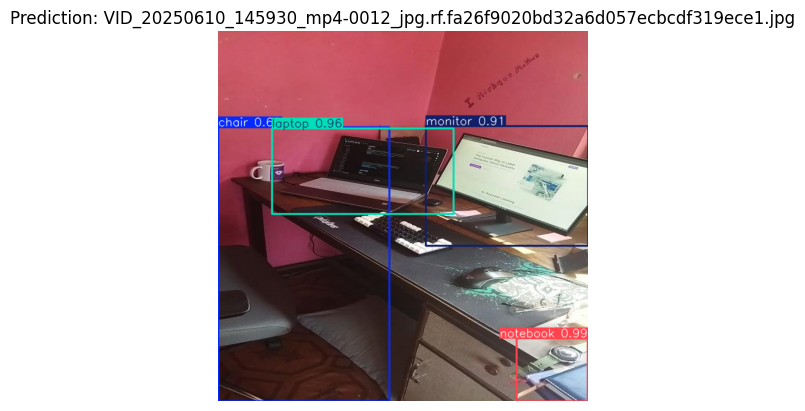


image 1/1 /content/TechManthan_Object_Detection-1/valid/images/VID_20250610_145930_mp4-0020_jpg.rf.37796ec6ec1c83fccff3e6acdedf354b.jpg: 640x640 1 laptop, 1 monitor, 1 notebook, 1 water_bottle, 11.3ms
Speed: 2.7ms preprocess, 11.3ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'chair', 1: 'cup', 2: 'keyboard', 3: 'laptop', 4: 'monitor', 5: 'mouse', 6: 'notebook', 7: 'plant', 8: 'water_bottle'}
obb: None
orig_img: array([[[ 61,  44, 141],
        [ 61,  44, 141],
        [ 61,  45, 139],
        ...,
        [220, 237, 233],
        [218, 235, 231],
        [215, 232, 228]],

       [[ 62,  45, 142],
        [ 62,  45, 142],
        [ 62,  46, 140],
        ...,
        [219, 236, 232],
        [209, 226, 222],
        [207, 224, 220]],

       [[ 63,  46, 143],
        [ 63,  46, 143],
        [ 63,  47, 141],
        ..

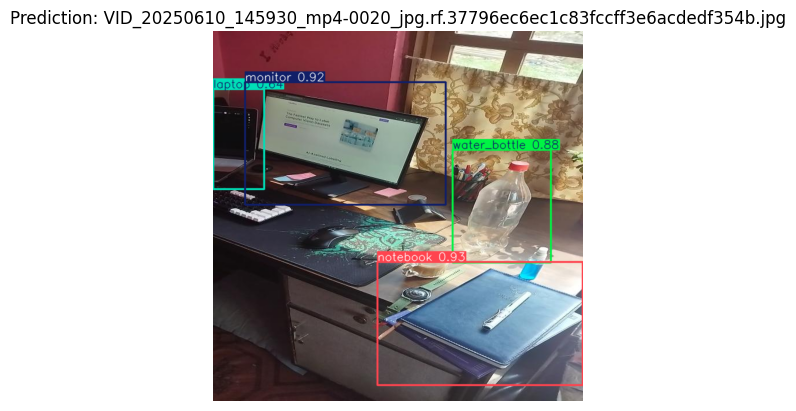


image 1/1 /content/TechManthan_Object_Detection-1/valid/images/VID_20250610_145930_mp4-0029_jpg.rf.8c03a99b7566f233c7c59edd0a10ccb9.jpg: 640x640 1 monitor, 1 notebook, 1 water_bottle, 9.9ms
Speed: 2.8ms preprocess, 9.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'chair', 1: 'cup', 2: 'keyboard', 3: 'laptop', 4: 'monitor', 5: 'mouse', 6: 'notebook', 7: 'plant', 8: 'water_bottle'}
obb: None
orig_img: array([[[ 24,  17,  68],
        [ 24,  17,  68],
        [ 24,  16,  69],
        ...,
        [206, 186, 209],
        [206, 185, 210],
        [206, 185, 210]],

       [[ 25,  18,  69],
        [ 25,  18,  69],
        [ 25,  17,  70],
        ...,
        [206, 186, 209],
        [206, 185, 210],
        [206, 185, 210]],

       [[ 26,  19,  70],
        [ 26,  19,  70],
        [ 26,  18,  71],
        ...,
        [

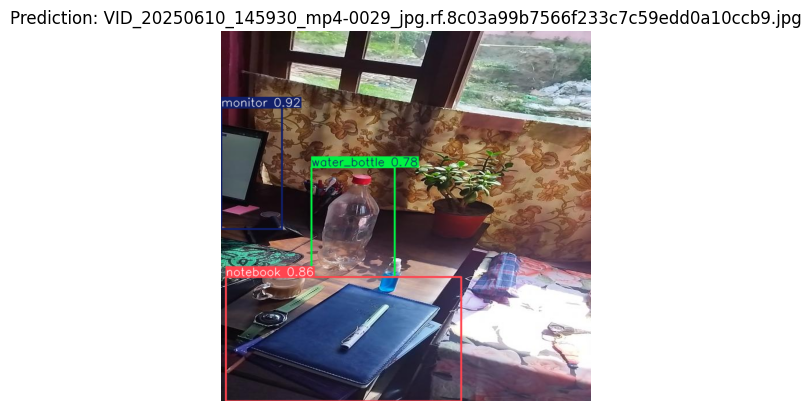


image 1/1 /content/TechManthan_Object_Detection-1/valid/images/VID_20250610_145930_mp4-0031_jpg.rf.53c72709828da1f4dfa1e56e4d2163dc.jpg: 640x640 1 monitor, 1 notebook, 1 plant, 1 water_bottle, 9.1ms
Speed: 2.8ms preprocess, 9.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'chair', 1: 'cup', 2: 'keyboard', 3: 'laptop', 4: 'monitor', 5: 'mouse', 6: 'notebook', 7: 'plant', 8: 'water_bottle'}
obb: None
orig_img: array([[[ 28,  17,  67],
        [ 28,  17,  67],
        [ 28,  17,  67],
        ...,
        [137, 149, 137],
        [130, 142, 130],
        [127, 139, 127]],

       [[ 28,  17,  67],
        [ 28,  17,  67],
        [ 28,  17,  67],
        ...,
        [142, 154, 142],
        [139, 151, 139],
        [140, 152, 140]],

       [[ 28,  17,  67],
        [ 28,  17,  67],
        [ 28,  17,  67],
        ...,


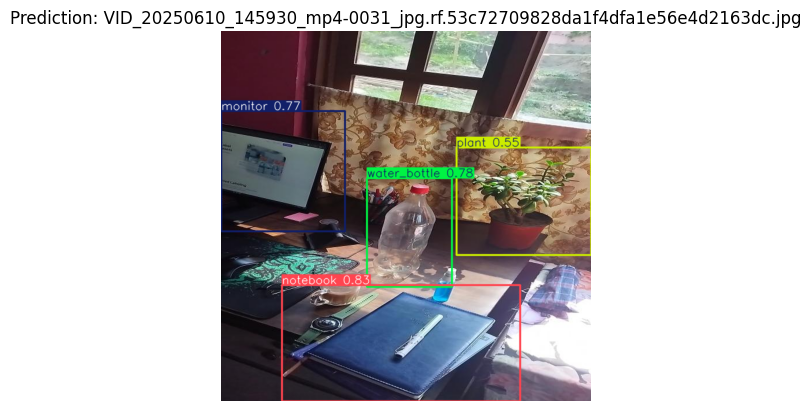

In [ ]:
import glob
import cv2
test_images = sorted(glob.glob('/content/TechManthan_Object_Detection-1/valid/images/*.jpg'))
for img in test_images:
  results = model(img)
  print(results)
  annotated_frame = results[0].plot()
  rgb_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
  plt.imshow(rgb_frame)
  plt.title(f"Prediction: {img.split('/')[-1]}")
  plt.axis('off')
  plt.show()